# 22 — Van der Waals dispersion: Grimme's D2

A semilocal functional cannot see a van der Waals bond. Its correlation energy is a
functional of the density *where the orbitals are*, and the London force comes from the
correlated fluctuations of two densities that do not overlap at all. Bilayer graphene is the
canonical demonstration: **PBE alone gives it no minimum in the interlayer separation**, and
the two layers drift apart.

Grimme's D2 ([J. Comp. Chem. **27**, 1787 (2006)](https://doi.org/10.1002/jcc.20495)) puts
the attraction back as a pair potential over the nuclei,

$$E_\mathrm{disp} = -\frac{s_6}{2}\sum_{ab\mathbf{R}}
   \frac{C_6^{ab}}{d_{ab\mathbf{R}}^{6}}\,f_\mathrm{damp}(d_{ab\mathbf{R}}),
\qquad
f_\mathrm{damp}(d) = \frac{1}{1 + e^{-\beta\,(d/(R_a + R_b) - 1)}},$$

with $C_6^{ab} = \sqrt{C_6^a C_6^b}$ from a table indexed by atomic number and $\beta = 20$.

**In this code it is the Ewald sum with a different radial function.** Both are a pair sum
over the nuclei and their periodic images; both fix their neighbour list on the host once, so
that the energy is a pure JAX function of the positions and the force is `jax.grad` of it;
both deform that list with the cell, so the stress is `jax.grad` in the other coordinate.
Nothing about D2 needed a new idea — which is why QE's two hand-derived routines
(`force_london`, `stres_london`) are here as a *test* rather than as the implementation.

Against the vendored `pw.x` on the same input: the total energy to **3.1e-9 Ry**, the
dispersion term to **4.9e-9 Ry**, the force to **3.7e-7 Ry/bohr** and the stress to
**4.1e-8 Ry/bohr³**. And the relaxation binds the bilayer at **6.10 bohr (3.23 Å)**, against
a measured 3.35 Å.

D2 is a pair sum over the **nuclei** and nothing else -- it never sees the density, which
is why the force and the stress are `jax.grad` of it in the two coordinates:

$$E_{\rm disp} = -\frac{s_6}{2} \sum_{i \neq j} \sum_{\mathbf L}
   \frac{C_6^{ij}}{|\mathbf r_{ij} + \mathbf L|^6}\;
   f_{\rm damp}\!\big(|\mathbf r_{ij} + \mathbf L|\big),
\qquad
f_{\rm damp}(R) = \frac{1}{1 + e^{-d\,(R/R_{\rm vdW} - 1)}}$$

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import read_qe_output
from pypresso.vdw.analytic import dispersion_force, dispersion_stress

CASES = Path("..") / "tests" / "data" / "qe"
PSEUDO = Path("..") / "tests" / "data" / "pseudo"

bilayer = Calculator.from_file(CASES / "graphene-bilayer-d2.in", pseudo_dir=PSEUDO,
                               announce=False, conv_thr=1e-10)
system, pseudos = bilayer.system, bilayer.pseudos
calculation = bilayer.calculation
reference = read_qe_output(CASES / "reference.out.graphene-bilayer-d2")

print(f"vdw_corr = {system.vdw_corr!r}, london_s6 = {system.london_s6}, "
      f"london_rcut = {system.london_rcut:g} bohr")
print(calculation.dispersion_sum.report([s.name for s in system.structure.species]))
print(f"\n  E_disp   {calculation.dispersion:.8f} Ry"
      f"      pw.x  {reference.energy_terms['dispersion']:.8f} Ry")

vdw_corr = 'grimme-d2', london_s6 = 0.75, london_rcut = 200 bohr
Parameters for Dispersion (Grimme-D2) Correction:
  atom      VdW radius       C_6
        C          2.744         60.710

  E_disp   -0.02305929 Ry      pw.x  -0.02305929 Ry


## 1. It is a function of the nuclei, and of nothing else

That sentence is the whole design, and it has a test sharper than any tolerance.
`electrons.f90` adds `elondon` to the total *after* the SCF loop, so the density, the
eigenvalues and the potential of a run with the correction must be **bit for bit** what the
same run without it produces — and the two totals must differ by exactly the printed
`Dispersion Correction`. A correction that had leaked into `v_of_rho` would still give a
plausible total energy and would fail this in the tenth decimal of the Hartree term.

In [2]:
# The same cell with `vdw_corr` absent -- a different input, so a different calculator.
plain = Calculator.from_file(CASES / "graphene-bilayer.in", pseudo_dir=PSEUDO,
                             announce=False, conv_thr=1e-10).get_scf()
corrected = bilayer.get_scf()

print("max |rho(D2) - rho(none)|        ",
      np.abs(np.asarray(plain.density) - np.asarray(corrected.density)).max())
print("max |eps(D2) - eps(none)|        ",
      np.abs(np.asarray(plain.eigenvalues) - np.asarray(corrected.eigenvalues)).max())
print(f"\nE(D2) - E(none)  {corrected.total_energy - plain.total_energy:+.10f} Ry")
print(f"E_disp           {corrected.energy_terms['dispersion']:+.10f} Ry")

qe = read_qe_output(CASES / "reference.out.graphene-bilayer")
print(f"\npw.x, same pair  {reference.total_energy - qe.total_energy:+.10f} Ry")

print(f"\n{'term':<16}{'pypresso':>16}{'pw.x':>16}{'difference':>14}")
for name, value in sorted(corrected.energy_terms.items()):
    other = reference.energy_terms.get(name)
    print(f"{name:<16}{value:>16.8f}{other:>16.8f}{value - other:>14.1e}")
print(f"{'total':<16}{corrected.total_energy:>16.8f}{reference.total_energy:>16.8f}"
      f"{corrected.total_energy - reference.total_energy:>14.1e}")

max |rho(D2) - rho(none)|         0.0
max |eps(D2) - eps(none)|         0.0

E(D2) - E(none)  -0.0230592851 Ry
E_disp           -0.0230592851 Ry

pw.x, same pair  -0.0230592800 Ry

term                    pypresso            pw.x    difference
dispersion           -0.02305929     -0.02305929       4.9e-09
ewald                11.66546446     11.66546446       7.9e-10
hartree              53.78895022     53.78896923      -1.9e-05
one-electron        -96.54073327    -96.54075437       2.1e-05
smearing             -0.00021298     -0.00021298       1.4e-09
xc                  -13.99480871    -13.99480662      -2.1e-06
total               -45.10439956    -45.10439956      -3.1e-09


## 2. The figure: what the correction is for

The electronic energy and the dispersion energy are **separately meaningful here**, which is
exactly the point above — the SCF never sees the correction, so one sweep of self-consistent
runs gives both curves at once. The PBE energies below were measured offline (thirteen SCF
runs, about six minutes); the dispersion energy at each separation is recomputed in this
cell, because it costs nothing.

PBE alone is repulsive all the way out. Adding $E_\mathrm{disp}$ — which is *monotonic*, with
no minimum of its own — produces one.

The sweep stops at 10 bohr and the curves are referred to that point, **not to infinity**:
the cell is 20 bohr tall, so at a separation of 10 bohr each layer is equidistant from its
neighbour and from its own periodic image, and past that the two swap roles and the curve
turns back up. The binding energy below is therefore a *lower* bound on the well depth.

binding energy   -17.8 meV per atom (a lower bound: see above)
PBE alone        -0.2 meV per atom at its lowest point -- no well
minimum at       6.10 bohr on this sweep (3.23 A); the BFGS relaxation gives 6.10


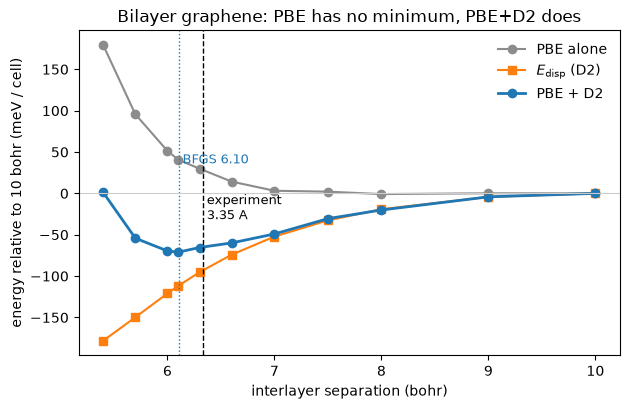

In [3]:
# Measured offline: thirteen SCF runs on the 12x12x1 grid at ecutwfc = 40.
SEPARATION = np.array([5.4, 5.7, 6.0, 6.1, 6.3, 6.6, 7.0, 7.5, 8.0, 9.0, 10.0])
E_PBE = np.array([-45.06839999, -45.0745402, -45.07779712, -45.07857165, -45.0793757, -45.08052449, -45.08134049, -45.08141908, -45.08163641, -45.08156401, -45.08157174])   # Ry, the total energy with no correction

height = float(np.asarray(system.cell.at)[2, 2])
crystal = np.asarray(system.structure.positions) @ np.linalg.inv(np.asarray(system.cell.at))

def dispersion_at(separation):
    "The pair sum at this interlayer separation -- no SCF, milliseconds."
    moved = crystal.copy()
    moved[:2, 2] = 0.5 - 0.5 * separation / height
    moved[2:, 2] = 0.5 + 0.5 * separation / height
    positions = jnp.asarray(moved @ np.asarray(system.cell.at))
    return float(calculation.dispersion_sum.energy(positions))

E_DISP = np.array([dispersion_at(d) for d in SEPARATION])
total = E_PBE + E_DISP
minimum = SEPARATION[total.argmin()]

fig, ax = plt.subplots(figsize=(6.4, 4.2))
zero = lambda y: (y - y[-1]) * 13605.7   # meV, referred to the widest separation
ax.plot(SEPARATION, zero(E_PBE), "o-", color="0.55", label="PBE alone")
ax.plot(SEPARATION, zero(E_DISP), "s-", color="tab:orange", label="$E_{\\rm disp}$ (D2)")
ax.plot(SEPARATION, zero(total), "o-", color="tab:blue", lw=2, label="PBE + D2")
ax.axvline(6.104, color="tab:blue", ls=":", lw=1)
ax.axvline(3.35 * 1.8897259886, color="k", ls="--", lw=1)
ax.annotate(" BFGS 6.10", xy=(6.104, 0.62), xycoords=("data", "axes fraction"),
            color="tab:blue", fontsize=9, va="top")
ax.annotate(" experiment\n 3.35 A", xy=(3.35 * 1.8897259886, 0.50),
            xycoords=("data", "axes fraction"), fontsize=9, va="top")
ax.axhline(0.0, color="0.8", lw=0.8)
ax.set_xlabel("interlayer separation (bohr)")
ax.set_ylabel("energy relative to 10 bohr (meV / cell)")
ax.set_title("Bilayer graphene: PBE has no minimum, PBE+D2 does")
ax.legend(frameon=False)
fig.tight_layout()

print(f"binding energy   {zero(total).min() / 4:.1f} meV per atom (a lower bound: see above)")
print(f"PBE alone        {zero(E_PBE).min() / 4:+.1f} meV per atom at its lowest point -- "
      "no well")
print(f"minimum at       {minimum:.2f} bohr on this sweep "
      f"({minimum / 1.8897259886:.2f} A); the BFGS relaxation gives 6.10")

## 3. The force and the stress are one gradient each

`force_london` and `stres_london` are 200 lines of Fortran between them. Here they are
`jax.grad` of the same scalar in two different coordinates: the positions, and the strain that
deforms the lattice translations the neighbour list is made of. QE's expressions *are*
transcribed — in `pypresso/vdw/analytic.py` — but only so that the two can be compared, and
`pw.x` at `verbosity = 'high'` prints both as blocks of their own, so the comparison is
against QE's own numbers rather than against a total.

In [4]:
positions = system.structure.positions
volume = float(system.cell.volume)
sum_ = calculation.dispersion_sum

autodiff_force = -jax.grad(sum_.energy)(positions)
transcribed_force = dispersion_force(sum_, positions)

def strained(strain):
    deformation = jnp.eye(3) + strain
    return sum_.at_cell(deformation).energy(positions @ deformation.T)

autodiff_stress = -jax.grad(strained)(jnp.zeros((3, 3))) / volume
transcribed_stress = dispersion_stress(sum_, positions, volume)

print("force, z component (Ry/bohr)")
print(f"{'atom':>6}{'jax.grad':>14}{'force_london':>15}{'pw.x':>14}")
for atom in range(4):
    print(f"{atom + 1:>6}{autodiff_force[atom, 2]:>14.8f}"
          f"{transcribed_force[atom, 2]:>15.8f}"
          f"{reference.force_terms['dispersion'][atom, 2]:>14.8f}")
print(f"\nmax |jax.grad - force_london|   "
      f"{np.abs(np.asarray(autodiff_force - transcribed_force)).max():.1e}")
print(f"max |force_london - pw.x|       "
      f"{np.abs(np.asarray(transcribed_force) - reference.force_terms['dispersion']).max():.1e}")
print(f"max |jax.grad - stres_london|   "
      f"{np.abs(np.asarray(autodiff_stress - transcribed_stress)).max():.1e}")
print(f"max |stres_london - pw.x|       "
      f"{np.abs(np.asarray(transcribed_stress) - reference.stress_terms['dispersion']).max():.1e}")

force, z component (Ry/bohr)
  atom      jax.grad   force_london          pw.x
     1    0.00173177     0.00173177    0.00173177
     2    0.00172333     0.00172333    0.00172333
     3   -0.00173177    -0.00173177   -0.00173177
     4   -0.00172333    -0.00172333   -0.00172333

max |jax.grad - force_london|   3.6e-17
max |force_london - pw.x|       3.9e-09
max |jax.grad - stres_london|   2.7e-19
max |stres_london - pw.x|       1.2e-08


## 4. One more derivative: the elastic constants

Because the correction reaches the stress through `Calculation.at_strain`, it reaches
everything built on top of that — including the **elastic constants**, which are one `jvp` of
the stress (notebook 21). And because it does *not* reach the Hamiltonian, it reaches nothing
built on the electronic response: $d\chi/dx$ is unchanged to **0.0**.

So the whole of what a van der Waals correction does to an electrostriction tensor is
predictable in advance: $m$ and $q$ — the *stress* coefficients — do not move at all, and $M$
and $Q$ — the *strain* ones — move only through the elastic compliance that converts them.
Measured on the silicon case P26 was checked on, with D2 switched on (unphysical, and exactly
the point: it isolates the machinery):

| | no D2 | with D2 | difference |
|---|---|---|---|
| $C_{11}$ (GPa) | 209.377 | 206.553 | -2.824 |
| $C_{12}$ (GPa) | 67.976 | 67.134 | -0.842 |
| $C_{44}$ (GPa) | 133.962 | 134.628 | +0.666 |
| $d\chi_{11}/dx_{11}$ | 197.015 | 197.015 | **0.0** |

and the difference column is reproduced, to **2.2e-18**, by the second derivative of the pair
sum alone — three lines of `jax.jvp` that share nothing with `elastic_constants`. The cell
below is that calculation, run on the bilayer instead of on silicon.

**The whole path runs on the bilayer too**, and not only D2's share of it:
`graphene-bilayer-electrostriction.in` puts this crystal through the third derivative, which
took a k-grid that misses `K` (graphene is a semimetal, and the response here is the
insulator one) and a mixing parameter the slab needs — QE's `alpha_mix = 0.7` *diverges*
there. Clamped ion: $C_{11} = 859.0$, $C_{12} = 26.5$, $C_{33} = 56.6$ GPa, reproducing a
five-point second difference of the energy to $5.8\times10^{-5}$, and $d\varepsilon/dx$
reproducing a central difference over re-converged strained cells to $2.2\times10^{-4}$.
Those are properties of the *supercell* — half of it is vacuum — so what they are quoted for
is the agreement.

Its **signs are worth a second look**, and they are not a mistake: every entry is negative.
The D2 pair potential has no minimum of its own — in its attractive tail $E \sim -C_6/r^6$ has
$d^2E/dr^2 < 0$ everywhere — so what binds the bilayer is D2's *slope* against PBE's, not its
curvature, and its contribution to the elastic constants is a **softening**. The positive
$C_{33}$ of the relaxed bilayer comes from PBE's repulsive wall; D2 moves where that wall is
met, and takes a couple of GPa off the stiffness once it is.

In [5]:
VOIGT = [(0, 0), (1, 1), (2, 2), (1, 2), (0, 2), (0, 1)]
from pypresso.response.elastic import RY_TO_GPA   # Ry/bohr^3 -> GPa

gradient = jax.grad(strained)
contribution = np.zeros((6, 6))
for column, (k, l) in enumerate(VOIGT):
    tangent = jnp.zeros((3, 3)).at[k, l].add(0.5).at[l, k].add(0.5)
    _, response = jax.jvp(gradient, (jnp.zeros((3, 3)),), (tangent,))
    response = 0.5 * (np.asarray(response) + np.asarray(response).T) / volume
    contribution[:, column] = [response[i, j] * RY_TO_GPA for (i, j) in VOIGT]

names = ["11", "22", "33", "23", "13", "12"]
print("what D2 adds to C_IJ of bilayer graphene, GPa")
print("      " + "".join(f"{n:>9}" for n in names))
for row, name in enumerate(names):
    print(f"{name:>4}  " + "".join(f"{contribution[row, c]:9.3f}" for c in range(6)))

what D2 adds to C_IJ of bilayer graphene, GPa
             11       22       33       23       13       12
  11     -6.024   -2.116   -1.123   -0.004   -0.000   -0.000
  22     -2.116   -6.024   -1.123    0.004   -0.000   -0.000
  33     -1.123   -1.123   -5.486   -0.000    0.000    0.000
  23     -0.004    0.004   -0.000   -0.763   -0.000   -0.000
  13     -0.000   -0.000    0.000   -0.000   -0.763   -0.004
  12     -0.000   -0.000   -0.000   -0.000   -0.004   -1.954


## What is not here

Four of the five corrections `set_vdw_corr` offers are **refused by name**, and the reason
splits them cleanly in two. **D3**'s $C_6$ depends on each atom's coordination number, so it
is a function of the geometry with a derivative of its own rather than a table lookup.
**Tkatchenko-Scheffler**, **MBD** and **XDM** rescale their coefficients by quantities built
from the self-consistent density — Hirshfeld volumes, the exchange hole — which puts them
*inside* `v_of_rho`, where D2 is outside it, and the null test in §1 is precisely what would
break. QE's `set_vdw_corr` prints a warning and runs on with no correction at all for a name
it does not recognise; an input asking for D3 and silently getting plain PBE is 30 meV on a
layered crystal with nothing in the output that greps as an error.

---

`PLAN.md` §3, phase **P27** — the traps (`rgen`'s fold, the sign of the separation vector,
and why a $1/r^6$ sum needs a 200-bohr cutoff), the convergence table, and why the two codes'
relaxations stop 0.48 bohr apart on a surface this flat.
Tests: `tests/unit/test_dispersion.py` and `tests/regression/test_dispersion.py`.